# 分类回归实战_依据val_acc使用早停_模型保存

实战步骤：

1、加载数据集，理解数据集 fashion_minst

2、搭建 class NeuralNetwork 模型

3、设置交叉熵损失函数，SGD 优化器

4、编写评估函数 evaluating

5、编写训练函数 train

6、开始训练 训练多少次

7、绘制损失、准确率曲线

## 1. 数据集预处理

In [1]:
# 计算数据集的均值和标准差
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# 首先加载数据（仅转换为Tensor，不进行其他预处理）
temp_transform = transforms.ToTensor()
temp_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=temp_transform)
temp_train_loader = DataLoader(temp_train_dataset, batch_size=64, shuffle=False)

# 初始化累加器
sum_pixels = 0.0
sum_squared_pixels = 0.0
total_pixels = 0

# 遍历所有数据计算均值和平方均值
print("正在计算训练集的均值和标准差...")
for images, _ in temp_train_loader:
    # images形状: [batch_size, 1, 28, 28]
    # 将所有像素值展平为一维
    pixels = images.view(-1)  # [batch_size * 1 * 28 * 28]
    
    # 累加所有像素值和像素值的平方
    sum_pixels += pixels.sum().item()
    sum_squared_pixels += (pixels ** 2).sum().item()
    total_pixels += pixels.numel()

# 计算总体均值 μ = (1/n) * Σ(x_i)
mean = sum_pixels / total_pixels

# 根据公式计算方差：σ² = (1/n) * Σ(x_i²) - μ²
mean_squared = sum_squared_pixels / total_pixels
variance = mean_squared - mean ** 2

# 计算标准差 σ = √σ²
std = variance ** 0.5

print(f"总像素数: {total_pixels}")
print(f"训练集均值 (μ): {mean:.6f}")
print(f"训练集标准差 (σ): {std:.6f}")
print(f"训练集方差 (σ²): {variance:.6f}")
print(f"\n验证计算:")
print(f"  (1/n) * Σ(x_i²) = {mean_squared:.6f}")
print(f"  μ² = {mean**2:.6f}")
print(f"  σ² = (1/n) * Σ(x_i²) - μ² = {mean_squared:.6f} - {mean**2:.6f} = {variance:.6f}")

# 保存均值和标准差供后续使用
dataset_mean = mean
dataset_std = std


正在计算训练集的均值和标准差...
总像素数: 47040000
训练集均值 (μ): 0.286041
训练集标准差 (σ): 0.353024
训练集方差 (σ²): 0.124626

验证计算:
  (1/n) * Σ(x_i²) = 0.206445
  μ² = 0.081819
  σ² = (1/n) * Σ(x_i²) - μ² = 0.206445 - 0.081819 = 0.124626


In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# 定义数据预处理：将图像转换为Tensor，并进行标准化
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为Tensor并归一化到[0, 1]
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std])  # 标准化
])

# 加载数据集
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 定义DataLoader参数
batch_size = 64

# 创建DataLoader对数据进行分批
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## 2. 搭建模型

In [3]:

from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # 展平输入，[batch, 1, 28, 28] -> [batch, 28*28]
        
        # 先初始化 Sequential
        self.network = nn.Sequential()
        
        # 第1层：784 -> 100
        self.network.add_module('fc1', nn.Linear(28*28, 100))
        self.network.add_module('relu1', nn.SELU())
        
        # 使用循环动态添加网络层
        # 中间18层，每层都是100 -> 100
        for i in range(18):
            self.network.add_module(f'fc{i+2}', nn.Linear(100, 100))
            self.network.add_module(f'relu{i+2}', nn.SELU())
        
        # 输出层：100 -> 10（不需要激活函数）
        self.network.add_module('fc20', nn.Linear(100, 10))

    # 前向传播方法，调用 model(x) 会自动调用 forward(x)
    def forward(self, x):
        x = self.flatten(x)  # 展平输入
        x = self.network(x)  # 自动按顺序依次执行每一层
        return x

In [4]:
# 模型测试

# 随机生成一个数据，形状为 (1, 1, 28, 28)
random_input = torch.randn(1, 1, 28, 28)

# 实例化模型
model = NeuralNetwork()

# 调用模型进行前向传播
output = model(random_input)

print("模型输出：")
print(output)


模型输出：
tensor([[ 0.0597, -0.1442,  0.0486,  0.0706,  0.0047,  0.0078, -0.0628, -0.0378,
         -0.1007,  0.0018]], grad_fn=<AddmmBackward0>)


## 3. 封装Trainer类进行训练与评估

Trainer 初始化完成
设备: cuda
损失函数: CrossEntropyLoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
训练集: 60000 个样本, 938 个批次
验证集: 10000 个样本, 157 个批次
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/classification_5)

开始训练模型
训练轮数: 40
训练集: 60000 个样本, 938 个批次
验证集: 10000 个样本, 157 个批次
设备: cuda
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/classification_5)

Epoch [1/40], Train Loss: 0.9486, Train Acc: 0.6374, Val Loss: 0.5795, Val Acc: 0.8074
Epoch [2/40], Train Loss: 0.5399, Train Acc: 0.8211, Val Loss: 0.5388, Val Acc: 0.8258
Epoch [3/40], Train Loss: 0.4864, Train Acc: 

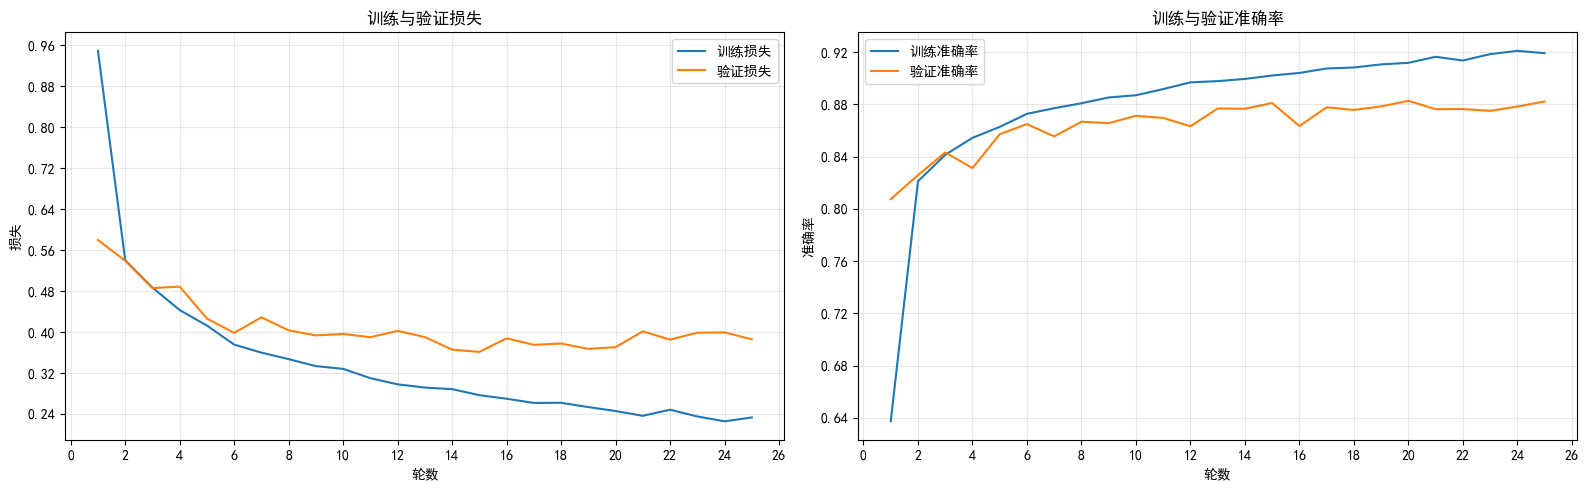

训练历史曲线绘制完成！


In [ ]:
# 导入 Trainer 模块
from Train_v3 import Trainer  # Train_v3添加早停功能和模型保存功能
import torch.optim as optim
import os

# 创建新的模型实例（如果之前已经训练过，可以创建新模型重新训练）
model_with_trainer = NeuralNetwork()

# 设置保存路径
notebook_name = 'classification_6'
save_dir = f'./checkpoints/{notebook_name}'
model_name = notebook_name

# 创建 Trainer 实例，传入模型和数据加载器
trainer = Trainer(
    model=model_with_trainer,
    train_loader=train_loader,
    val_loader=test_loader,
    early_stopping=True,  # 启用早停
    patience=5,  # 早停耐心值
    monitor='val_acc',  # 依据val_acc早停
    min_delta=0.001,  # 最小改善幅度
    restore_best_weights=True,  # 恢复最佳模型权重
    save_best_model=True,  # 保存最佳模型
    save_dir=save_dir,  # 保存目录
    model_name=model_name  # 模型名称
)

# 开始训练（使用 Trainer 类）
num_epochs = 40
trainer.train(num_epochs=num_epochs)

# 使用 Trainer 进行最终评估
print("\n" + "=" * 60)
print("最终模型评估")
print("=" * 60)
final_loss, final_acc = trainer.evaluating()
print(f"最终测试损失: {final_loss:.4f}")
print(f"最终测试准确率: {final_acc:.4f}")

# 使用 Trainer 绘制训练历史曲线
trainer.plot_history()



### 与使用ReLU作为激活函数的模型训练评估结果比较

验证结果明显更好，且梯度消失问题成功得到解决